<a href="https://colab.research.google.com/github/AquilaITOH/MedicalDataScience-exercises/blob/main/26_Medical_DataScience_06_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# メディカルデータサイエンス #6 畳み込みニューラルネットワーク (Convolutional Neural Networks: cNN)

## 放射線医学、放射線技術学分野でのAIの適用例
1. 画像解析、診断支援

    画像認識と分類: 異常な組織、腫瘍の検出、指摘

2. 画像品質向上

    ノイズ低減、アーチファクト除去

3. 放射線治療の最適化

    セグメンテーション支援、治療計画の選択

### 画像認識

本講義では画像認識と分類を扱う

- classification: 画像分類
- detection: 物体検出
- segmentation: セグメンテーション(輪郭検出)

[人工知能による画像診断支援: 概念から応用まで](https://www.jstage.jst.go.jp/article/mii/37/2/37_11/_pdf)

植田大樹, “人工知能による画像診断支援: 概念から応用まで,” 医用画像情報学会雑誌, vol. 37, no. 2, pp. 11–20, 2020, doi: 10.11318/mii.37.11

## ここまでのまとめ CNNの基本構成

入力された画像を畳み込み層で局所特徴量を抽出、プーリング層で位置普遍性を確保する。

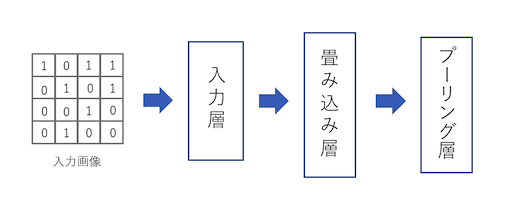

[畳み込みニューラルネットワーク(CNN)をわかりやすく基本から実装まで解説 – <体験型>学習ブログ by zero to one](https://zero2one.jp/learningblog/cnn-for-beginners/)

## GPUランタイムに接続されていることを確認
GPU Nameが 'Tesla T4'ならば’ok

In [ ]:
!nvidia-smi

##データ分析の準備

### ライブラリの読み込み(2025/6)
Theanoバックエンドは開発中止されたため、tensorflow.kerasを使用する。

In [ ]:
# tensorflow.kerasの必要なコンポーネントをインポート
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
# from keras.utils import np_utils
from tensorflow.keras.utils import to_categorical  # Replaced np_utils with to_categor

from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

### ラベル付き手書き数字画像データの読み込み

ラベルの付けられた手書き数字画像データセット MNIST data setを使う。

In [ ]:
# Scikit-learn経由でMNISTのオリジナルデータをダウンロードする。
# 手書き文字 70,000文字のラベル付きデータセット

mnist_X, mnist_y = fetch_openml('mnist_784', version=1, data_home=".", return_X_y=True)

#x_all = mnist_X.astype(np.float32) / 255
#y_all = mnist_y.astype(np.int32)
# 説明変数と目的変数に切り分ける
# X, y = mnist['data'], mnist['target']

#### 説明変数(数字画像)と目的変数(ラベル)のサイズとデータ型、データ形式を確認

In [ ]:
# numpyのshape関数を使ってXのサイズとデータ形、データ形式を確認
print(mnist_X.shape)
print(mnist_X.dtypes)
print(type(mnist_X).__module__)
print(mnist_y.shape)
print(mnist_y.dtypes)
print(type(mnist_y).__module__)
#print('mnist_Xはnparray?' );
#print(type(mnist_X).__module__ == np.__name__)
#print(type(mnist_X).__module__)

#### 手書き数字画像を一つ見てみる

まずは数字のまま配列として見る


In [ ]:
# Xの53230番目のデータをtest_numberへ切り出す
test_number = mnist_X.loc[53230,:]

# reshape関数を使って784を28x28へ変換する
#test_number_image = test_number.reshape(28,28) #dataframe objectのままではreshapedできない　'DataFrame' object has no attribute 'reshape'
test_number_image = test_number.values.reshape(28,28)

# pandasのカラム表示の設定を変更
pd.options.display.max_columns = 28

# Numpy配列からPandasのデータフレームへ変換
number_matrix = pd.DataFrame(test_number_image)

# number_matrixの表示
number_matrix

#### 手書き文字画像データを画像化して表示する

In [ ]:
# imshowを使って表示test_number_image（Numpy配列）を画像で表示
%matplotlib inline

plt.imshow(test_number_image, cmap = matplotlib.cm.binary,
           interpolation='nearest')
plt.show()

#### ラベル(教師データ)を確認

正解が数字で記入されている

In [ ]:
# 53230番目のYの値を出力
print(mnist_y[53230])

### 前処理

単純パーセプトロンやDNNでIrisを分類した時と同様、データの前処理を行う。

#### データの分割


トレーニングデータとテストデータに分割する

- X_train: トレーニング用データ 60,000
- X_test: テスト用データ 10,000
- y_tarain: トレーニング用正解ラベル 60,000
- y_test: テスト用正解ラベル 10,000

In [ ]:
# 訓練データとテストデータを切り分ける
X_train, X_test, y_train, y_test = mnist_X.loc[:59999], mnist_X.loc[60000:], mnist_y[:60000], mnist_y[60000:]
y_test_backup = y_test

# 両方のサイズを確認
print(X_train.shape)
print(X_test.shape)


#### リサイズ

In [ ]:
# 28x28x1のサイズへ変換する
X_train = X_train.values.reshape(X_train.shape[0], 28, 28,1)
X_test = X_test.values.reshape(X_test.shape[0], 28, 28,1)


#### 濃度値のスケーリング

In [ ]:
# データタイプをfloat32へ変換
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# 正規化（ピクセルの最大値は255）
X_train /= 255
X_test /= 255

#### 前処理 ターゲットを1hot形式に変換する

出力層で1つのみビットが立つ形にする

In [ ]:
# ターゲットとなるyを1hot形式に変換
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# y_testの1を表示
y_test[1]

### ニューラルネットワークの作成

In [ ]:
# モデルの宣言
model = Sequential()

# 先に作成したmodelへレイヤーを追加
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28,28,1))) #3x3の畳み込み
model.add(MaxPooling2D(pool_size=(2, 2))) #2x2へプーリング
model.add(Dropout(0.25)) #ドロップアウト
model.add(Flatten()) #ベクトル化
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax')) #出力

# Learnig Processの設定
model.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

#### 構築したモデルの確認

表形式で確認

In [ ]:
# 構築したモデルの確認
print(model.summary())

#### フローチャート形式で確認

In [ ]:
# モデルの可視化
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    show_shapes=True,
)

#### modelの模式図

input - 畳み込み - プーリング - Dropout - flatton(5408node) - 128node - output(1hot)

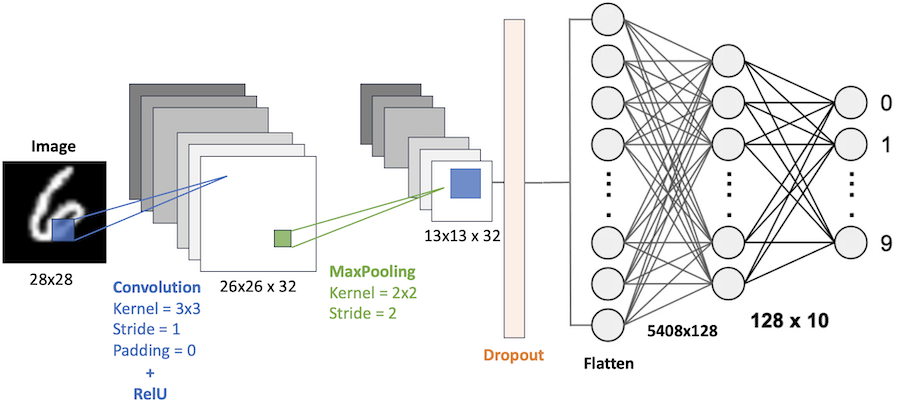

## 学習

トレーニングデータによる予測モデル学習

In [ ]:
# モデルの訓練（エポック １０）
# 注意 - CPUランタイムで実行すると、10〜15分程度かかります
# model.fit(X_train, y_train, epochs=10)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

各行の読み方：

| 項目 | 意味 |
|------|------|
| `Epoch X/10` | 現在何周目の学習か（全10周） |
| `1875/1875` | 1エポック内のバッチ処理進捗（60,000枚 ÷ 32 = 1,875バッチ） |
| **`accuracy`** | **訓練データ**での正答率（例：0.9765 → 97.65%） |
| **`loss`** | 訓練データでの損失値（小さいほど良い） |
| **`val_accuracy`** | **テストデータ**での正答率（例：0.9776 → 97.76%） |
| **`val_loss`** | テストデータでの損失値 |

ポイントとして、`accuracy`（訓練データ）より `val_accuracy`（テストデータ）の方が汎化性能の指標として重要。エポックを重ねるごとに両方が上昇していれば、学習が順調に進んでいる証拠。

## 評価

テストデータによる推論を行い、精度評価

In [ ]:
# テストデータを使ってモデルの評価
loss_and_metrics = model.evaluate(X_test, y_test, batch_size=128)
print(loss_and_metrics)


| 項目 | 値 | 意味 |
|------|-----|------|
| `79/79` | バッチ数 | 10,000枚 ÷ batch_size(128) ≒ 79バッチ |
| `accuracy: 0.9776` | 97.76% | テスト10,000枚中の正答率 |
| `loss: 0.0698` | 損失値 | 小さいほど良い |

`print(loss_and_metrics)` の出力リスト `[loss, accuracy]` は順番が固定で、**インデックス0がloss、インデックス1がaccuracy**です。

In [ ]:
# テストデータの数確認
print(X_test.shape)

#### 個々のサンプルの推論結果


In [ ]:
# X_testを使って推論を行う
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
y = list(y_test_backup)

# 各クラス（0〜9）の確率を列として展開
prob_df = pd.DataFrame(predictions, columns=[f'P(={i})' for i in range(10)])
prob_df = prob_df.round(4)  # 小数点4桁に丸める

# Actual（正解）と Predicted（予測）を先頭に追加
prob_df.insert(0, 'Actual', y)
prob_df.insert(1, 'Predicted', predicted_classes)

prob_df[1:50]

`Predictions`列の10個の数値は各クラス（0〜9）に対する確率。最大値のインデックスが予測クラス。例えば1行目は3番目の値（インデックス2）が0.9995なので「2」と予測しており、`Actual = 2` と一致。

#### 推論を誤った例を確認する

In [ ]:
# X_testの8番目のデータをtest_numberへ切り出す
test_number = X_test[8,:]
print(test_number.shape)
test_number_image = np.squeeze(test_number)

# pandasのカラム表示の設定を変更
pd.options.display.max_columns = 28

# Numpy配列からPandasのデータフレームへ変換
number_matrix = pd.DataFrame(test_number_image)

# number_matrixの表示
number_matrix

In [ ]:
# imshowを使って表示test_number_image（Numpy配列）を画像で表示
%matplotlib inline

plt.imshow(test_number_image, cmap = matplotlib.cm.binary,
           interpolation='nearest')
plt.show()

## 学習過程の表示

学習を繰り返すほど損失関数が減少している

In [ ]:
#ニューラルネットワークの学習過程を可視化してみよう – 株式会社ライトコード
#https://rightcode.co.jp/blog/information-technology/neural-network-learning-visualization
metrics = ['loss', 'accuracy']  # 使用する評価関数を指定

plt.figure(figsize=(10, 5))  # グラフを表示するスペースを用意

for i in range(len(metrics)):

    metric = metrics[i]

    plt.subplot(1, 2, i+1)  # figureを1×2のスペースに分け、i+1番目のスペースを使う
    plt.title(metric)  # グラフのタイトルを表示

    plt_train = history.history[metric]  # historyから訓練データの評価を取り出す
    plt_test = history.history['val_' + metric]  # historyからテストデータの評価を取り出す

    plt.plot(plt_train, label='training')  # 訓練データの評価をグラフにプロット
    plt.plot(plt_test, label='test')  # テストデータの評価をグラフにプロット
    plt.legend()  # ラベルの表示

plt.show()  # グラフの表示

## Conv2Dの畳み込み積分のカーネルを確認

3x3のカーネルが32個ある

cNNは、どんなカーネルを学習したのだろうか？

In [ ]:
weights = model.get_layer("conv2d").get_weights()[0]
weights.shape

### カーネルを表示する

0番目のカーネルを可視化

- 数列表現
- 画像化

In [ ]:
w = weights[:, :, :, 0].copy()
m = w.min()
M = w.max()
w = (w-m)/(M-m)
plt.imshow(w, cmap = "gray")
print(w)

### 全てのカーネルを画像で表示

エッジ検出するカーネルが複数見られる

In [ ]:
# 畳み込みニューラルネットワークの畳み込み層の重みを可視化する方法 | NHN テコラス Tech Blog | AWS、機械学習、IoTなどの技術ブログ
# https://techblog.nhn-techorus.com/archives/8813
from PIL import Image
result = Image.new("L", (3*8+(8-1), 3*8+(8-1)))
w_s = np.squeeze(weights) # サイズ1の次元を削除
for i in range(32):
    w= w_s[:, :, i].copy()
    M = w.max()
    m = w.min()
    w = (w-m)/(M-m)
    w *= 255
    img = Image.fromarray(w.astype("uint8"), mode = "L")
    result.paste(img, (3*(i%8) + (i%8), 3*(i//8) + (i//8)))
plt.imshow(result, cmap = "gray")

## 次回使用教材

次回は胸部と腹部の放射線画像を分類するモデルを学びます

>Lakhani, P., Gray, D. L., Pett, C. R., Nagy, P. & Shih, G. Hello World Deep Learning in Medical Imaging. J Digit Imaging 31, 2018; 283-289, doi: 10.1007/s10278-018-0079-6

[Hello World Deep Learning in Medical Imaging](https://link.springer.com/article/10.1007/s10278-018-0079-6)